# Project 1: Does National Wealth Predict Health? GDP per Capita and Life Expectancy Across Countries

**Luxor Bourommavong | DTSC 2301 | Personal Portfolio Project 1**

## 1. Problem Definition

**Research Question:** Is a country's GDP per capita associated with life expectancy at birth, and does this relationship differ across income groups and world regions?

**Context:** Economists and public health researchers have long studied how much a country's wealth actually buys in terms of population health. The "Preston curve" (Preston, 1975) is one of the most cited findings in demography: life expectancy rises steeply with income at low income levels, but the relationship flattens out at higher income levels, meaning additional wealth buys progressively less additional health. Understanding whether this pattern still holds with recent data matters for organizations like the UN, WHO, and World Bank when deciding whether health-specific investment, rather than general economic investment, is likely to have the larger impact in a given country.

**Why it matters / who cares:** Governments, NGOs, and international development agencies use exactly this kind of cross-country evidence to justify targeted health interventions (for example, concluding that income growth alone won't meaningfully reduce child mortality in a region, and that direct health investment is needed instead). As someone interested in humanitarian data analysis, this question sits directly at the intersection of economics and public health outcomes.

## 2. Data Description

**Source:** World Bank Open Data / World Development Indicators, accessed via the public World Bank API (no authentication required).
- GDP per capita (current US$) — indicator `NY.GDP.PCAP.CD`
- Life expectancy at birth, total (years) — indicator `SP.DYN.LE00.IN`
- Country metadata (region, income group) — World Bank `country` endpoint

**Unit of analysis:** one row per country, for the year 2021 (the most recent year with near-complete coverage across both indicators at the time of writing).

**Key variables (conceptualized & operationalized):**

| Variable | Concept | Operationalization |
|---|---|---|
| `gdp_per_capita` | National economic wealth per person | GDP per capita in current US dollars (World Bank indicator `NY.GDP.PCAP.CD`) |
| `life_expectancy` | Population health outcome | Life expectancy at birth in years, both sexes (World Bank indicator `SP.DYN.LE00.IN`) |
| `region` | Geographic grouping | World Bank region classification (e.g., Sub-Saharan Africa, Europe & Central Asia) |
| `income_group` | Economic development tier | World Bank income classification (Low, Lower-middle, Upper-middle, High income) |

**Size & assumptions:** The World Bank tracks about 217 countries/economies, plus a number of regional and income-group aggregates that are *not* individual countries. After merging the two indicators with the country metadata and removing missing values (Section 3), the working dataset covers roughly 190+ actual countries. A key assumption is that a single year (2021) is representative; GDP per capita and life expectancy don't swing dramatically year to year for most countries, but 2021 values are still partly shaped by COVID-19 pandemic effects on both economic output and mortality, which is discussed further in Section 6.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

YEAR = 2021

In [2]:
def fetch_indicator(indicator_code, year):
    """Fetch one World Bank indicator for all countries/entities in a given year."""
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
    params = {"format": "json", "per_page": 20000, "date": year}
    response = requests.get(url, params=params)
    records = response.json()[1]
    return pd.DataFrame([
        {
            "country_code": row["countryiso3code"],
            "country_name": row["country"]["value"],
            "value": row["value"],
        }
        for row in records
    ])

gdp_df = fetch_indicator("NY.GDP.PCAP.CD", YEAR).rename(columns={"value": "gdp_per_capita"})
life_df = fetch_indicator("SP.DYN.LE00.IN", YEAR).rename(columns={"value": "life_expectancy"})

# A handful of World Bank income-group aggregates (e.g. "High income", "Low income")
# are returned with a *blank* ISO3 country code instead of a real one. Left in place,
# these blank codes all collide with each other during the merge below and silently
# multiply the row count. Drop them here, before merging.
gdp_df = gdp_df[gdp_df["country_code"].str.strip() != ""]
life_df = life_df[life_df["country_code"].str.strip() != ""]

print(f"GDP rows: {len(gdp_df)}, Life expectancy rows: {len(life_df)}")

GDP rows: 260, Life expectancy rows: 260


In [3]:
# Country metadata: region + income group, used both to add context and to
# filter out World Bank "aggregate" entities (e.g. "World", "High income")
# that share the indicator API's country list but are not actual countries.
meta_response = requests.get(
    "https://api.worldbank.org/v2/country", params={"format": "json", "per_page": 400}
)
meta_records = meta_response.json()[1]
meta_df = pd.DataFrame([
    {
        "country_code": c["id"],
        "region": c["region"]["value"],
        "income_group": c["incomeLevel"]["value"],
    }
    for c in meta_records
])

meta_df.head()

,country_code,region,income_group
0,ABW,Latin America & Caribbean,High income
1,AFE,Aggregates,Aggregates
2,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,AFR,Aggregates,Aggregates
4,AFW,Aggregates,Aggregates


In [4]:
df = gdp_df.merge(life_df[["country_code", "life_expectancy"]], on="country_code", how="inner")
df = df.merge(meta_df, on="country_code", how="left")

print(f"Rows after merging GDP + life expectancy + metadata: {len(df)}")
df.head()

Rows after merging GDP + life expectancy + metadata: 260


,country_code,country_name,gdp_per_capita,life_expectancy,region,income_group
0,AFE,Africa Eastern and Southern,1560.894626,62.979999,Aggregates,Aggregates
1,AFW,Africa Western and Central,2116.938294,57.355015,Aggregates,Aggregates
2,ARB,Arab World,6708.207619,70.404114,Aggregates,Aggregates
3,CSS,Caribbean small states,13996.447507,69.922811,Aggregates,Aggregates
4,CEB,Central Europe and the Baltics,19224.328774,74.723283,Aggregates,Aggregates


## 3. Data Cleaning and Preparation

Three cleaning decisions matter most here:

1. **Dropping blank-code aggregate rows before merging.** A handful of World Bank income-group aggregates (e.g. "High income", "Low income") are returned by the indicator API with a *blank* ISO3 country code instead of a real one. Left alone, every blank-code row collides with every other blank-code row during a merge on `country_code`, silently inflating the row count (I caught this because the merged dataset had *more* rows than either source indicator, which shouldn't be possible for an inner join). These are dropped immediately after fetching, before any merging happens.
2. **Removing remaining aggregate entities.** The country-indicator API also returns regional and income-group aggregates that *do* carry a real-looking code (e.g. "World", "European Union"). These would distort a country-level analysis, so they are filtered out using the `region` field from the country metadata: real countries always belong to a named geographic region, while aggregates are tagged `"Aggregates"`.
3. **Dropping missing values.** A handful of countries are still missing GDP per capita or life expectancy for 2021, often small island nations or countries in active conflict where data collection is difficult (see Section 6). Rather than impute these, I drop them, since imputing macroeconomic or health indicators for conflict-affected states risks manufacturing misleading data for exactly the cases most relevant to humanitarian analysis.

In [5]:
before = len(df)
df = df[df["region"] != "Aggregates"].copy()
print(f"Dropped {before - len(df)} aggregate/non-country rows")

before = len(df)
df = df.dropna(subset=["gdp_per_capita", "life_expectancy"])
print(f"Dropped {before - len(df)} rows with missing GDP per capita or life expectancy")

df = df.reset_index(drop=True)
print(f"Final cleaned dataset: {len(df)} countries")
df.describe()

Dropped 43 aggregate/non-country rows
Dropped 7 rows with missing GDP per capita or life expectancy
Final cleaned dataset: 210 countries


,gdp_per_capita,life_expectancy
count,210.000000,210.000000
mean,20464.458503,71.846180
std,30946.920948,7.728168
min,264.172844,40.279000
25%,2609.387460,66.506250
50%,7268.899459,72.204024
75%,27283.918479,77.513000
max,223823.327192,85.532683


## 4. Visualizations and Insights

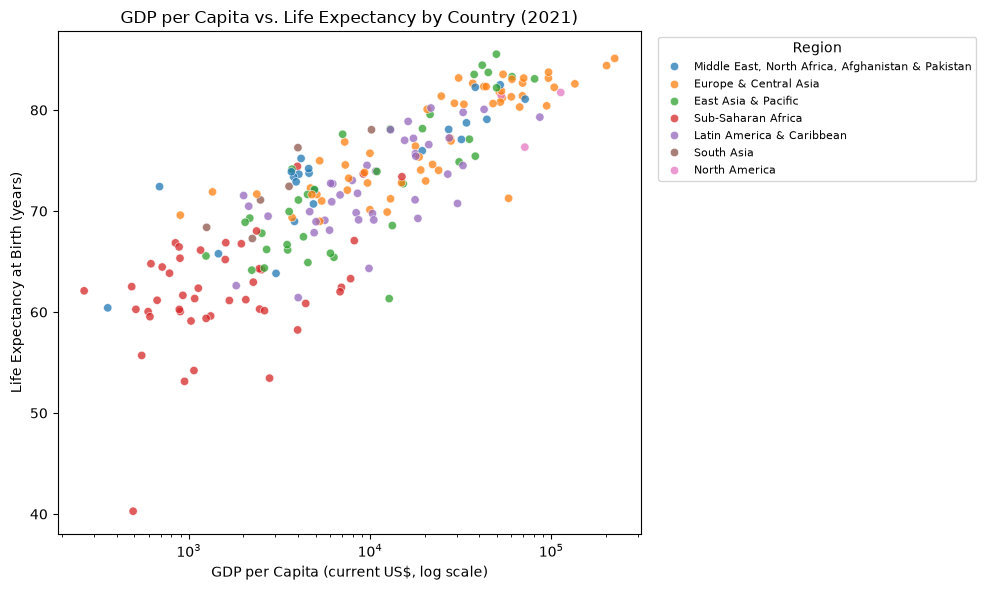

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="gdp_per_capita", y="life_expectancy", hue="region", alpha=0.75)
plt.xscale("log")
plt.xlabel("GDP per Capita (current US$, log scale)")
plt.ylabel("Life Expectancy at Birth (years)")
plt.title(f"GDP per Capita vs. Life Expectancy by Country ({YEAR})")
plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Insight:** The scatterplot shows a clear "Preston curve" shape: life expectancy rises steeply as GDP per capita increases from very low levels, but the curve flattens sharply above roughly \$20,000–\$30,000 per capita, meaning countries far richer than that (concentrated in North America and Europe & Central Asia) gain very little additional life expectancy from large additional increases in income. Sub-Saharan African countries cluster in the lower-left (low income, lower life expectancy), while Europe & Central Asia and North America cluster in the upper-right. A few countries sit noticeably above the general trend relative to their income level, suggesting factors besides raw GDP, such as public health infrastructure, are doing real work here too.

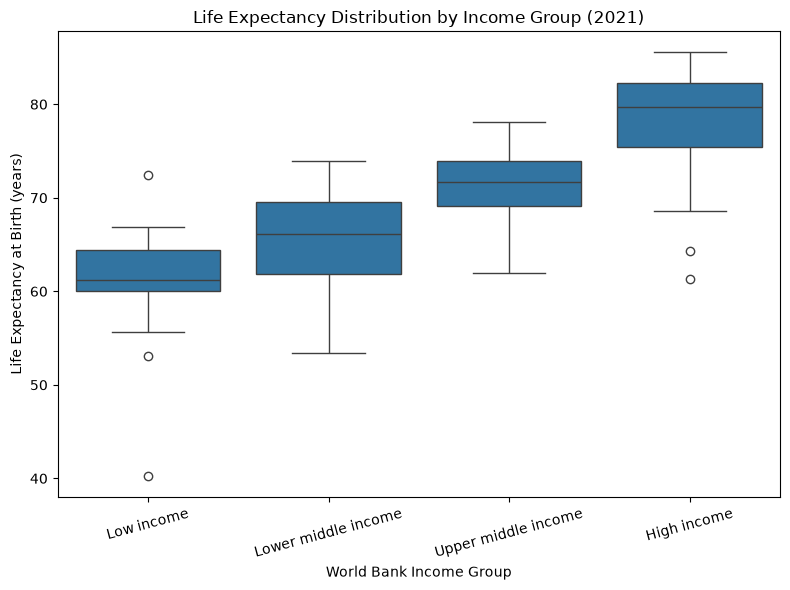

In [7]:
income_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="income_group", y="life_expectancy", order=income_order)
plt.xlabel("World Bank Income Group")
plt.ylabel("Life Expectancy at Birth (years)")
plt.title(f"Life Expectancy Distribution by Income Group ({YEAR})")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Insight:** The boxplot shows the same pattern from a different angle: median life expectancy climbs across income tiers, but the size of each jump shrinks at higher tiers — the gain from low income to lower-middle income is much larger than the gain from upper-middle to high income. The low-income group also has the widest spread and the most low-end outliers, meaning income group alone doesn't fully predict outcomes for the poorest countries: some low-income countries achieve notably higher life expectancy than their income peers.

## 5. Storytelling and Narrative

Together, the two visualizations tell a consistent story: **GDP per capita and life expectancy are strongly related, but the relationship is not linear and not straightforwardly causal.** Wealth appears to buy a lot of health at the bottom of the income distribution, where extra income likely funds basic needs like nutrition, clean water, and access to care, but delivers diminishing returns once a country crosses into upper-middle or high income territory, where health outcomes are shaped more by healthcare system quality, public health policy, and lifestyle factors than by additional income alone.

**What would be incorrect to conclude:** It would be a mistake to read this data as proof that raising a country's GDP *causes* longer life expectancy. This is observational, cross-sectional data; the correlation could run in the other direction (healthier populations are more economically productive), or both variables could be driven by a third factor such as institutional quality or political stability. The academic literature (Pritchett & Summers, 1996; Deaton, 2003) explicitly grapples with this causality question, and both caution against a simple "money buys health" interpretation.

## 6. Limitations, Ethics, and Reflection

**What this dataset fails to capture:** Country-level averages hide enormous within-country inequality; a country's average life expectancy can mask large gaps between its wealthiest and poorest citizens, or between urban and rural populations. GDP per capita is a mean, not a median, so it is skewed upward by very wealthy individuals in unequal economies.

**Potential biases and collection gaps:** Low-income and conflict-affected countries, often exactly the countries most relevant to humanitarian analysis, are also the countries most likely to have missing, delayed, or lower-quality data. Both indicators had a handful of nulls, disproportionately concentrated in small island nations and states experiencing conflict, which were dropped during cleaning rather than analyzed. 2021 data is also still partly shaped by the acute phase of the COVID-19 pandemic, which temporarily distorted both GDP (economic shocks and recovery stimulus) and life expectancy (excess mortality) in ways that may not reflect longer-run trends.

**What I'd explore next:** With more time, I would pull a multi-year panel (for example, 2000–2023) instead of a single cross-section, which would let me look at each country's trajectory rather than a single snapshot, and separate the pandemic-era shock from the longer-term relationship. I would also want to bring in a health-system-specific variable, such as health expenditure per capita or physicians per 1,000 people, to test whether it explains the diminishing-returns pattern better than raw GDP alone.

## 7. Code and Transparency

**Repository:** [Data-Science-Portfolio](https://github.com/lbouromm-sketch/Data-Science-Portfolio) — this notebook is linked from the Projects page of my portfolio site.

**Data sources:**
- World Bank. (2024). *World Development Indicators: GDP per capita (current US$)* [Data set]. https://data.worldbank.org/indicator/NY.GDP.PCAP.CD
- World Bank. (2024). *World Development Indicators: Life expectancy at birth, total (years)* [Data set]. https://data.worldbank.org/indicator/SP.DYN.LE00.IN
- World Bank. (n.d.). *Country and lending groups* [Data set]. https://api.worldbank.org/v2/country

**AI usage disclosure:** I used Claude (Anthropic, Claude Code CLI, Sonnet 5 model) to help structure this notebook: specifically, drafting the data retrieval and cleaning code, generating the two visualizations, and drafting portions of the written narrative, all of which I reviewed and edited myself. *(Please confirm this matches your course's exact AI disclosure policy before submitting, and adjust the wording if needed.)*

## References

Deaton, A. (2003). Health, inequality, and economic development. *Journal of Economic Literature, 41*(1), 113–158. https://doi.org/10.1257/002205103321544710

Preston, S. H. (1975). The changing relation between mortality and level of economic development. *Population Studies, 29*(2), 231–248. https://doi.org/10.1080/00324728.1975.10410201

Pritchett, L., & Summers, L. H. (1996). Wealthier is healthier. *Journal of Human Resources, 31*(4), 841–868. https://doi.org/10.2307/146149